In [1]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import median_filter



In [2]:
ds = xr.open_zarr("/Users/ivanr/Developer/ai-vineyard-productivity/agrixel-fair-dockerV2/data/output/files/SENTINEL-2/TEST000/cube.zarr", consolidated=False)
ds['variable'] = ds['variable'].astype('str')
print(ds)

<xarray.Dataset> Size: 291kB
Dimensions:   (time: 1, variable: 5, y: 112, x: 129)
Coordinates:
  * time      (time) datetime64[ns] 8B 2023-01-12T10:44:11
  * variable  (variable) <U4 80B 'B02' 'B03' 'B04' 'B08' 'NDVI'
  * y         (y) float64 896B 5.067e+06 5.067e+06 ... 5.066e+06 5.066e+06
  * x         (x) float64 1kB 1.679e+05 1.679e+05 ... 1.692e+05 1.692e+05
Data variables:
    data      (time, variable, y, x) float32 289kB ...
Attributes:
    crs:        EPSG:3857
    res_m:      10.0
    height:     112
    width:      129
    transform:  [10.0, 0.0, 167899.53819300234, 0.0, -10.0, 5067099.495777417]
    variables:  ['B02', 'B03', 'B04', 'B08', 'NDVI']
    time_iso:   ['2023-01-12T10:44:11Z']


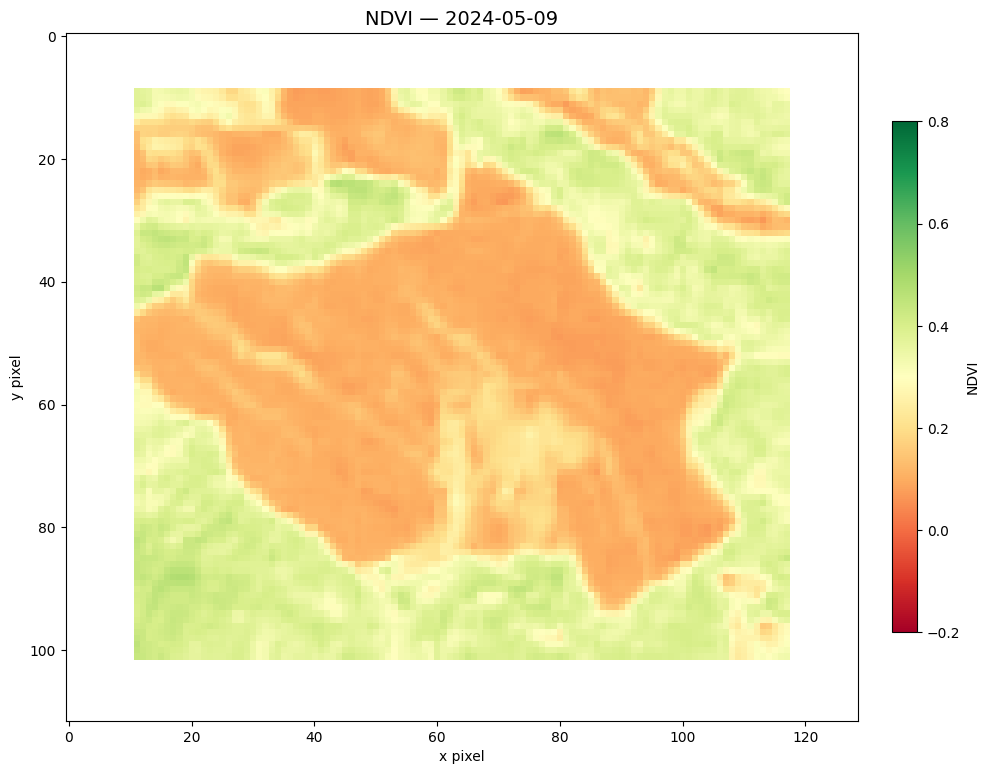

In [3]:

# Plot NDVI
ndvi = ds['data'].sel(variable='NDVI').isel(time=0).values  # shape (y, x)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(
    ndvi,
    cmap='RdYlGn',
    vmin=-0.2,
    vmax=0.8,
    origin='upper',
)
plt.colorbar(im, ax=ax, label='NDVI', fraction=0.03, pad=0.04)
ax.set_title('NDVI — 2024-05-09', fontsize=14)
ax.set_xlabel('x pixel')
ax.set_ylabel('y pixel')
plt.tight_layout()
plt.show()


## Sentinel-1 SAR Processing

Load the Sentinel-1 GRD cube (VV + VH polarizations) and compute:
- **RVI** (Radar Vegetation Index): `4 * VH / (VV + VH)`
- **SAR False Color** composite: R=VV, G=VH, B=VH/VV

In [5]:
s1 = xr.open_zarr(
    "/Users/ivanr/Developer/ai-vineyard-productivity/agrixel-fair-dockerV2/data/output/files/SENTINEL-1/cube.zarr",
    consolidated=False,
)
s1['variable'] = s1['variable'].astype('str')
print(s1)
print(f"\nVariables: {s1['variable'].values}")
print(f"Times:     {s1['time'].values}")

<xarray.Dataset> Size: 6MB
Dimensions:   (time: 2, variable: 2, y: 570, x: 628)
Coordinates:
  * time      (time) datetime64[ns] 16B 2024-05-05T06:01:43 2024-05-06T17:47:16
  * variable  (variable) <U2 16B 'VV' 'VH'
  * y         (y) float64 5kB 5.12e+06 5.12e+06 5.12e+06 ... 5.115e+06 5.115e+06
  * x         (x) float64 5kB 1.068e+05 1.069e+05 ... 1.131e+05 1.131e+05
Data variables:
    data      (time, variable, y, x) float32 6MB ...
Attributes:
    crs:        EPSG:3857
    res_m:      10.0
    height:     570
    width:      628
    transform:  [10.0, 0.0, 106841.87405178921, 0.0, -10.0, 5120250.461740777]
    variables:  ['VV', 'VH']
    time_iso:   ['2024-05-05T06:01:43Z', '2024-05-06T17:47:16Z']

Variables: ['VV' 'VH']
Times:     ['2024-05-05T06:01:43.000000000' '2024-05-06T17:47:16.000000000']


σ₀ VV (dB) — p2/p98: [-54.15216446 -41.8013382 ]
σ₀ VH (dB) — p2/p98: [-58.87394714 -47.85580063]


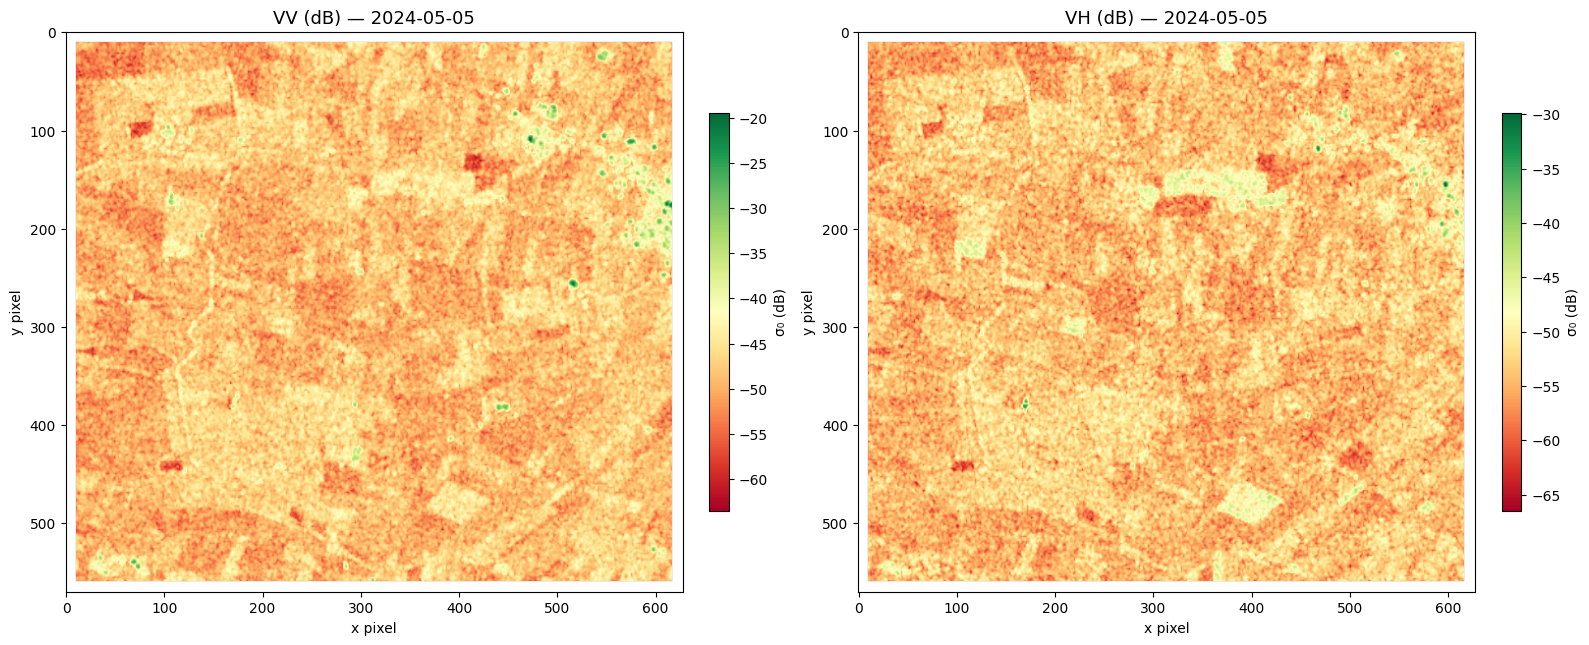

In [26]:
# Extract VV and VH for first time step
t_idx = 0
vv_raw = s1['data'].sel(variable='VV').isel(time=t_idx).values
vh_raw = s1['data'].sel(variable='VH').isel(time=t_idx).values
time_label = str(s1['time'].values[t_idx])[:10]

# Data are digital numbers (DN). Convert to sigma0 (linear): σ₀ = DN² / 10⁹
# Then to dB: σ₀_dB = 10 * log10(σ₀)
vv = vv_raw ** 2 / 1e9
vh = vh_raw ** 2 / 1e9

# Mask nodata
valid = (vv_raw > 0) & (vh_raw > 0)

vv_db = np.full_like(vv, np.nan)
vh_db = np.full_like(vh, np.nan)
vv_db[valid] = 10 * np.log10(vv[valid])
vh_db[valid] = 10 * np.log10(vh[valid])

print(f"σ₀ VV (dB) — p2/p98: {np.nanpercentile(vv_db, [2, 98])}")
print(f"σ₀ VH (dB) — p2/p98: {np.nanpercentile(vh_db, [2, 98])}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, img, title in zip(axes, [vv_db, vh_db], ['VV (dB)', 'VH (dB)']):
    im = ax.imshow(img, cmap='RdYlGn', origin='upper')
    ax.set_title(f'{title} — {time_label}', fontsize=13)
    ax.set_xlabel('x pixel')
    ax.set_ylabel('y pixel')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='σ₀ (dB)')
plt.tight_layout()
plt.show()

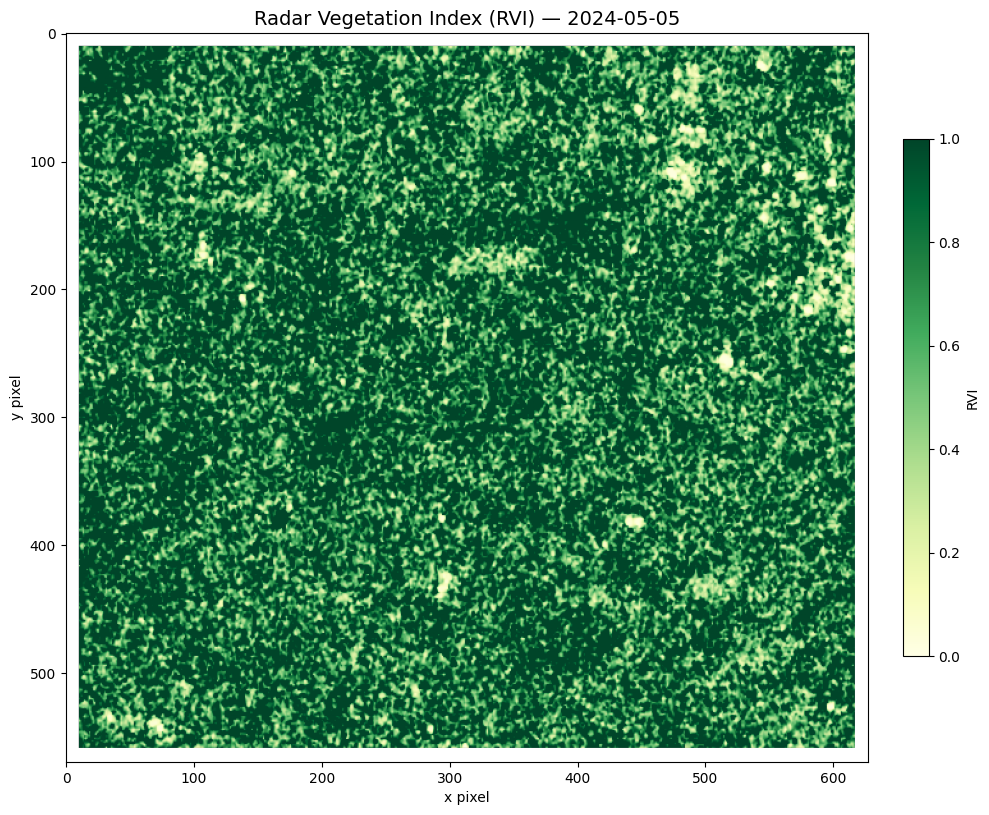

In [22]:
# Radar Vegetation Index: RVI = 4 * σ₀_VH / (σ₀_VV + σ₀_VH)
# Ranges 0–1; higher values indicate more vegetation / volume scattering
# Uses sigma0 linear power (not DN)
rvi = np.full_like(vv, np.nan)
rvi[valid] = (4 * vh[valid]) / (vv[valid] + vh[valid])

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(rvi, cmap='YlGn', vmin=0, vmax=1, origin='upper')
plt.colorbar(im, ax=ax, label='RVI', fraction=0.03, pad=0.04)
ax.set_title(f'Radar Vegetation Index (RVI) — {time_label}', fontsize=14)
ax.set_xlabel('x pixel')
ax.set_ylabel('y pixel')
plt.tight_layout()
plt.show()

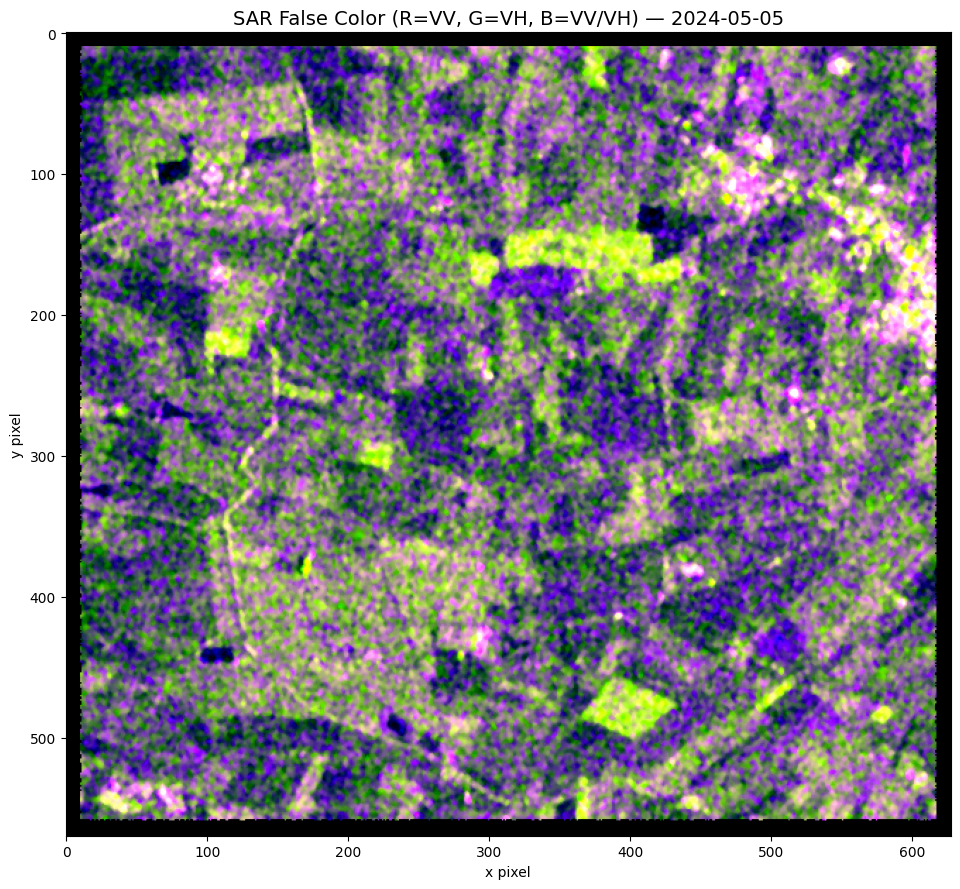

In [23]:
# SAR False Color Composite (VV, VH, VV/VH in dB with median filter)

eps = 1e-10

vv_db = 10 * np.log10(vv + eps)
vh_db = 10 * np.log10(vh + eps)

vv_db = median_filter(vv_db, size=3)
vh_db = median_filter(vh_db, size=3)

# Mask out nodata (original zero-backscatter pixels → ~-100 dB)
valid = (vv > 0) & (vh > 0) & np.isfinite(vv_db) & np.isfinite(vh_db)

# Ratio in dB (equivalent to VV/VH in linear)
ratio_db = vv_db - vh_db
def normalize(band, mask, pmin=2, pmax=98):
    vmin, vmax = np.percentile(band[mask], (pmin, pmax))
    out = np.clip(band, vmin, vmax)
    out = (out - vmin) / (vmax - vmin + eps)
    out[~mask] = 0
    return out

vv_n = normalize(vv_db, valid)
vh_n = normalize(vh_db, valid)
ratio_n = normalize(ratio_db, valid)

rgb = np.stack([vv_n, vh_n, ratio_n], axis=-1)

fig, ax = plt.subplots(figsize=(10, 9))
ax.imshow(rgb, origin='upper')
ax.set_title(f'SAR False Color (R=VV, G=VH, B=VV/VH) — {time_label}', fontsize=14)
ax.set_xlabel('x pixel')
ax.set_ylabel('y pixel')
plt.tight_layout()
plt.show()